# IL-2 receptor expression in colorectal cancer immune hubs

Dataset: *Spatially organized multicellular immune hubs in human colorectal cancer* (Broad Single Cell Portal, [SCP1162](https://singlecell.broadinstitute.org/single_cell/study/SCP1162)).
See `data/README.md` for download instructions.

In [ ]:
# Imports directs
import gc
import gzip
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Imports spécifiques
from scipy.io import mmread
from scipy.sparse import csc_matrix
from scipy.stats import f_oneway, ttest_ind
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import umap

# Import de la bibliothèque de fonctions (dossier src/)
import sys
sys.path.append("../src")
import bibli_immuno_ia
from bibli_immuno_ia import import_data
from bibli_immuno_ia import QC_violin
from bibli_immuno_ia import filter_cells 
from bibli_immuno_ia import normalize
from bibli_immuno_ia import apply_PCA , apply_umap
from bibli_immuno_ia import cluster_kmeans
from bibli_immuno_ia import plot_2D_projection
from bibli_immuno_ia import plot_umap
from bibli_immuno_ia import plot_umap_with_annotations
from bibli_immuno_ia import plot_umap_cluster_labels
from bibli_immuno_ia import plot_gene_umap
from bibli_immuno_ia import plot_violin
from bibli_immuno_ia import plot_violin_with_significance 
from bibli_immuno_ia import annotate_clusters
from bibli_immuno_ia import plot_expression_heatmap
from bibli_immuno_ia import t_test_gene_expression_with_pvalues
from bibli_immuno_ia import mann_whitney_gene_expression 

genes_of_interest = ["IL2RG", "IL2RA", "IL2RB"]  # Liste des gènes à tester

# Analyse du jeu de donnée : "Spatially organized multicellular immune hubs (colorectal cancer)"

### Import des données 

In [5]:
matrix_path = "../data/colorectal/matrix.mtx.gz"
genes_path = "../data/colorectal/genes.tsv"
barcodes_path = "../data/colorectal/barcodes.tsv"      

df2,genes,cells,matrix = import_data(matrix_path, genes_path, barcodes_path)

Data loaded: (43282, 371223)


### QC avant filtrage des données 

Comptage des gènes exprimés par cellule...
Calcul du nombre de gènes exprimés par cellule terminé.
Calcul du nombre d'UMI par cellule...
Calcul du nombre d'UMI par cellule terminé.
Calcul du pourcentage de gènes mitochondriaux...
Calcul du pourcentage de gènes mitochondriaux terminé.


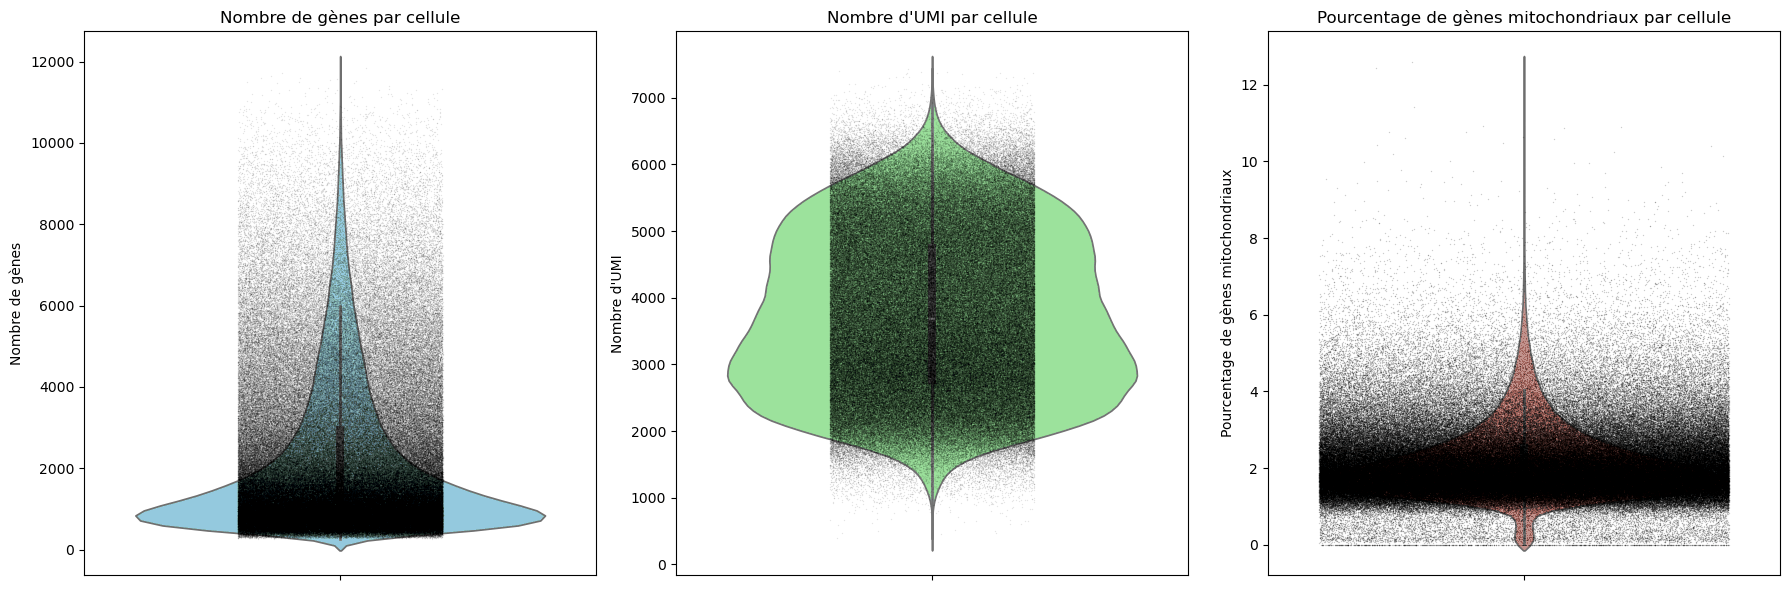

In [7]:
genes_per_cell, umi_per_cell, mitochondrial_percent = QC_violin(df2, genes)

### Filtrage des données 

In [9]:
df2_filtered = filter_cells(df2, genes, min_gene =200, max_gene = 2000, max_mito = 10)

Nombre de cellules avant filtrage : 371223
Nombre de cellules après filtrage : 179829


### QC après filtrage des données

Comptage des gènes exprimés par cellule...
Calcul du nombre de gènes exprimés par cellule terminé.
Calcul du nombre d'UMI par cellule...
Calcul du nombre d'UMI par cellule terminé.
Calcul du pourcentage de gènes mitochondriaux...
Calcul du pourcentage de gènes mitochondriaux terminé.


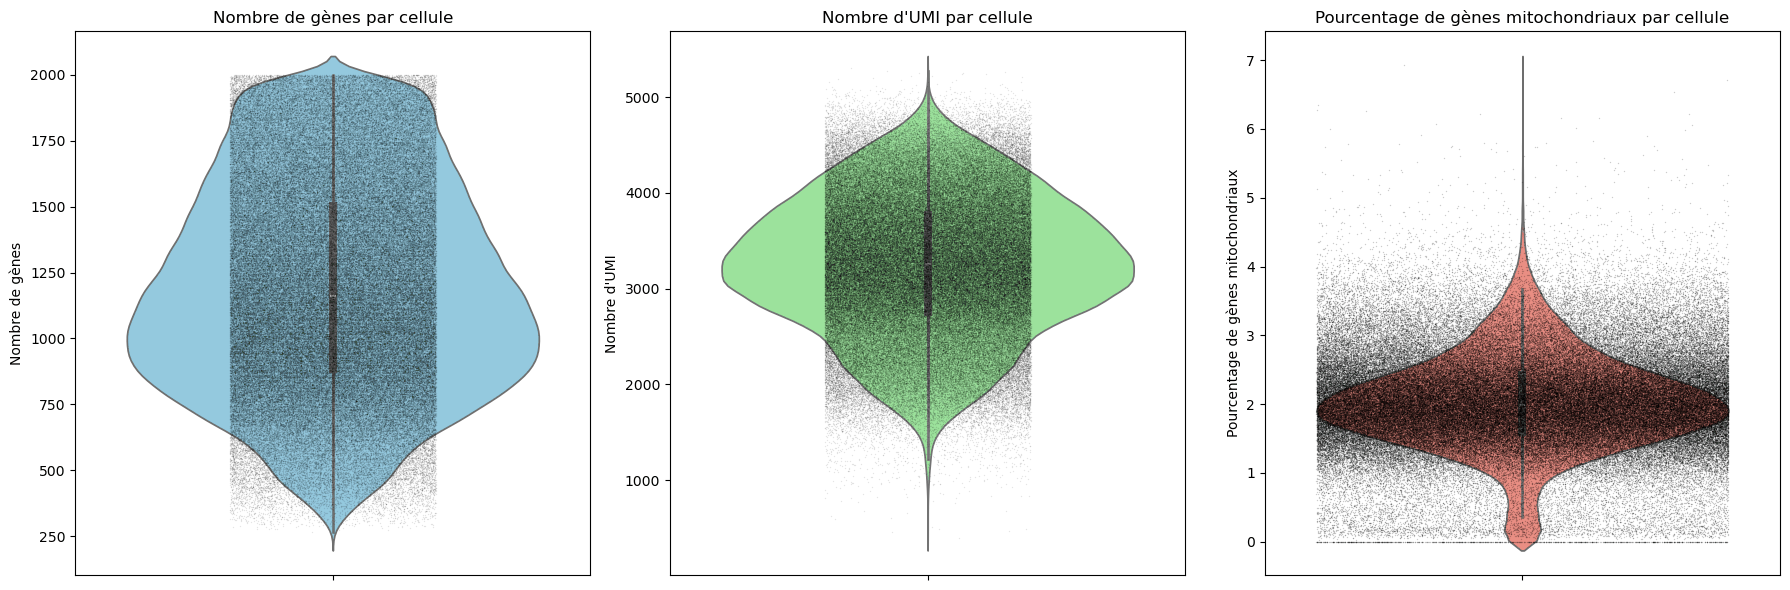

In [11]:
genes_per_cell, umi_per_cell, mitochondrial_percent = QC_violin(df2_filtered, genes)

### Normalisation 

In [13]:
df2_normalized = normalize(df2_filtered)

### Réduction de dimensionnalité 

#### PCA

In [16]:
pca_result2 =  apply_PCA(df2_normalized, n_components=20)

On applique la log transformation...
Log transformation complète.
Début de l'ACP
PCA complète, dimension = (179829, 20)


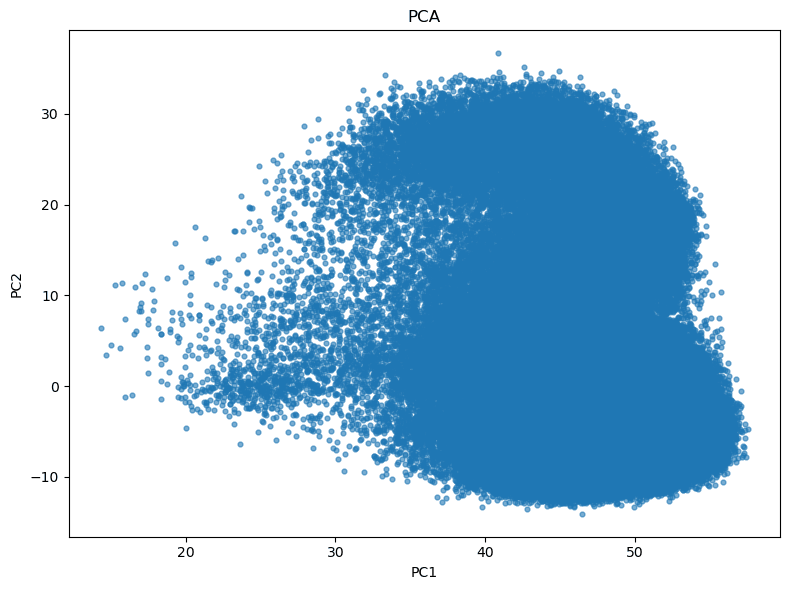

In [61]:
plot_2D_projection(pca_result2[:, :2], title="PCA", x_label="PC1", y_label="PC2")

#### UMAP

In [62]:
umap2 = apply_umap(pca_result2, n_neighbors=15, min_dist=0.4)

UMAP done: (179829, 2)


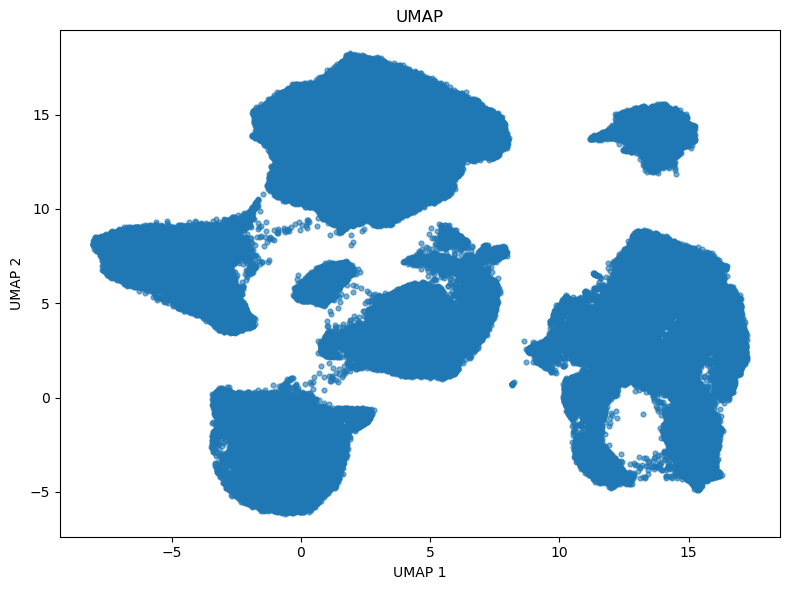

In [63]:
plot_2D_projection(umap2, title="UMAP", x_label="UMAP 1", y_label="UMAP 2")

### Clustering 

In [64]:
clusters2 = cluster_kmeans(umap2, n_clusters=50)

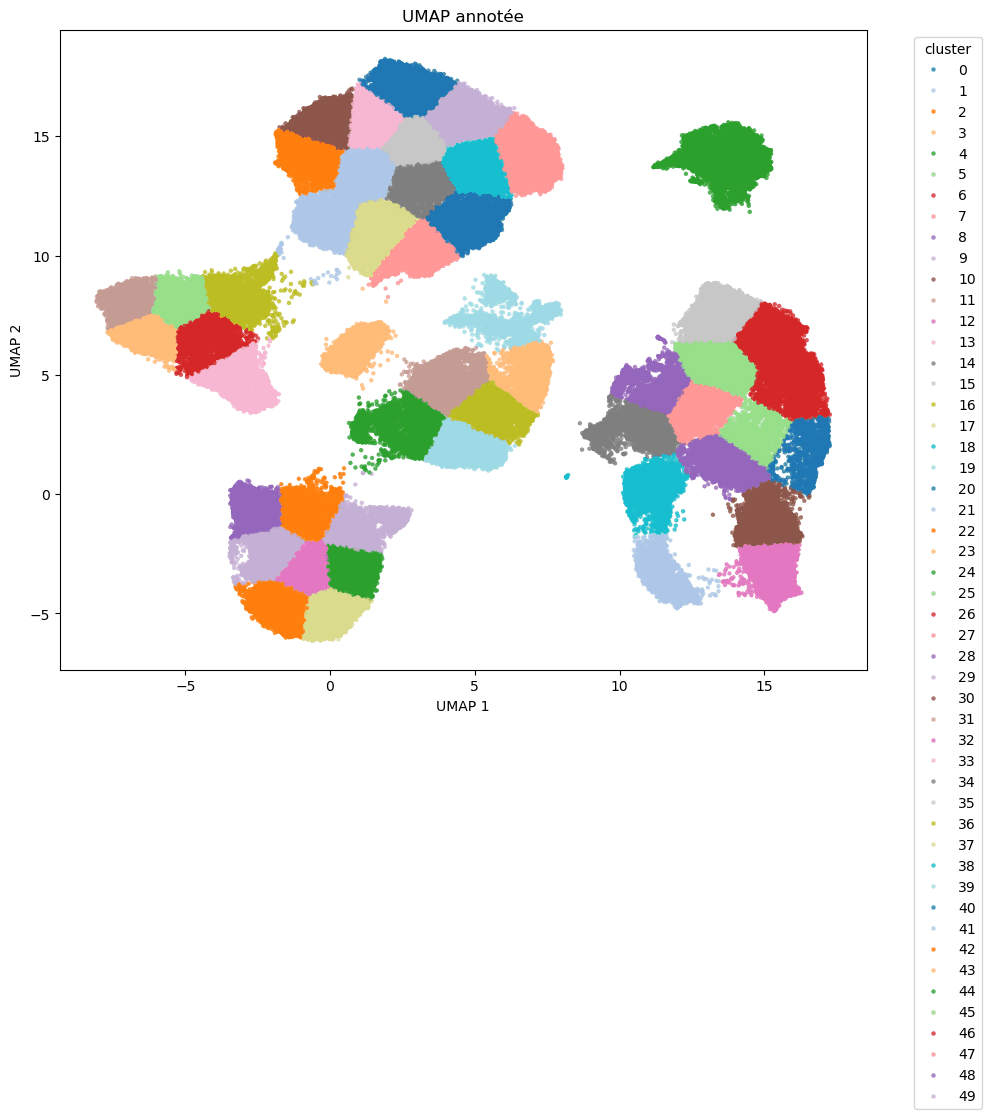

In [48]:
plot_umap(umap2, clusters2)

### Annotation des clusters 


🔎 Cluster 0 :
IL2RA        : 0.00
IL2RB        : 0.00
IL2RG        : 0.98
CD3E         : 0.01
CD4          : 0.00
CD8A         : 0.00
CD19         : 0.00
MS4A1        : 0.01
CD14         : 0.32
CD16         : ❌ Non trouvé
NCAM1        : 0.00
FCGR3A       : 0.00
IL7R         : 0.01
FOXP3        : 0.00
TNFRSF4      : 0.00
CTLA4        : 0.00
CXCR5        : 0.00
ICOS         : 0.00
CCR7         : 0.00
SELL         : 0.01
PRF1         : 0.00
GZMB         : 0.03
XBP1         : 0.59
MZB1         : 0.14
CD38         : 0.00
CLEC9A       : 0.00
CD209        : 0.00
ITGAX        : 0.00
CD68         : 0.42
CD163        : 0.01
MRC1         : 0.00
CD45         : ❌ Non trouvé

🔎 Cluster 1 :
IL2RA        : 0.14
IL2RB        : 3.05
IL2RG        : 3.80
CD3E         : 6.78
CD4          : 0.06
CD8A         : 3.41
CD19         : 0.01
MS4A1        : 0.04
CD14         : 0.04
CD16         : ❌ Non trouvé
NCAM1        : 0.26
FCGR3A       : 0.91
IL7R         : 1.48
FOXP3        : 0.03
TNFRSF4      : 0.28
CTLA4 

,Cluster,Cell Type
0,0,Autres/Indeterminé
1,1,Effector CD8+ T
2,2,Autres/Indeterminé
3,3,Monocytes classiques
4,4,Autres/Indeterminé
5,5,B cells
6,6,Autres/Indeterminé
7,7,Activated Tregs
8,8,Autres/Indeterminé
9,9,Activated Tregs


Cell Type
Autres/Indeterminé      72762
Effector CD8+ T         38709
Monocytes classiques    18964
Activated Tregs         12693
B cells                 12181
T cells                  7138
Macrophages              6525
Plasma cells             5105
Naive CD4+ T             3211
Plasmablasts             2541
Name: count, dtype: int64

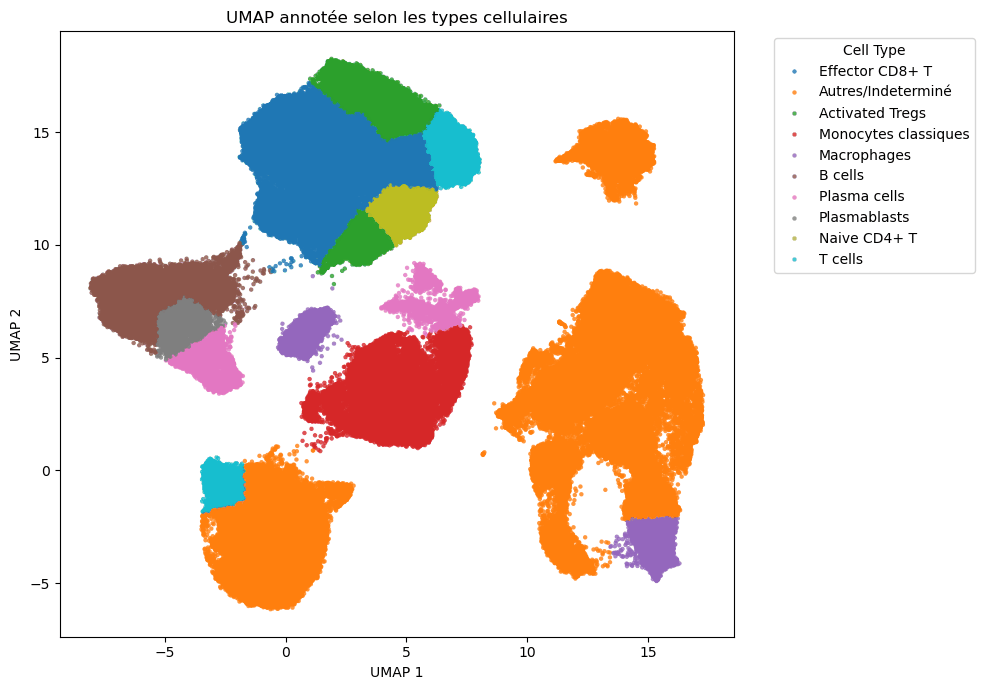

In [65]:
annotation_df, cell_type_per_cell, cluster_annotation = annotate_clusters(df2_normalized, clusters2, umap2)

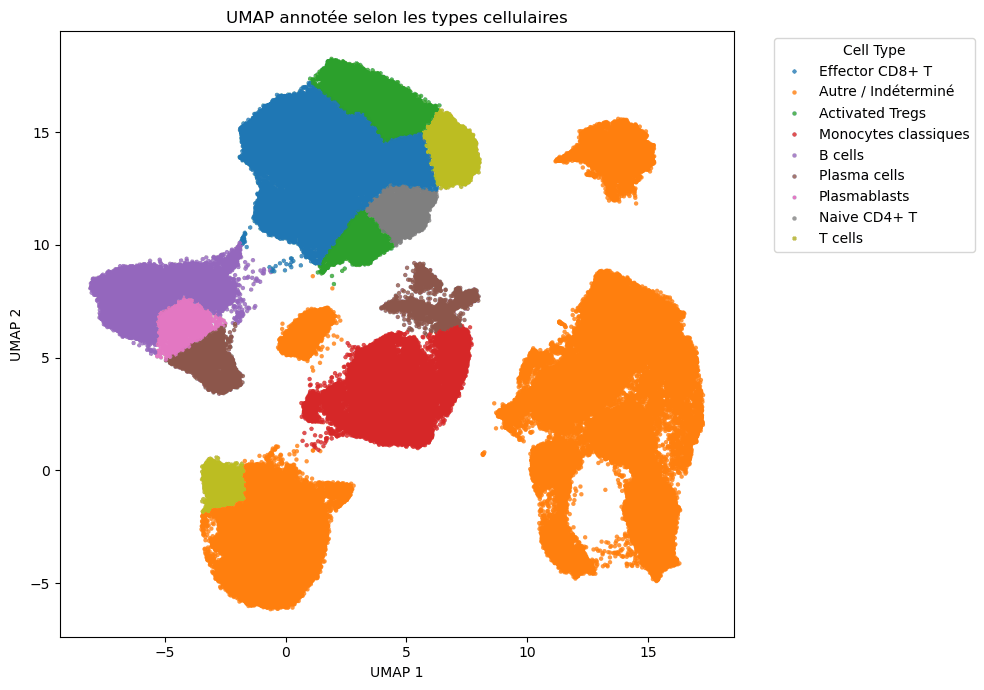

In [63]:
plot_umap_with_annotations(umap2, cell_type_per_cell)

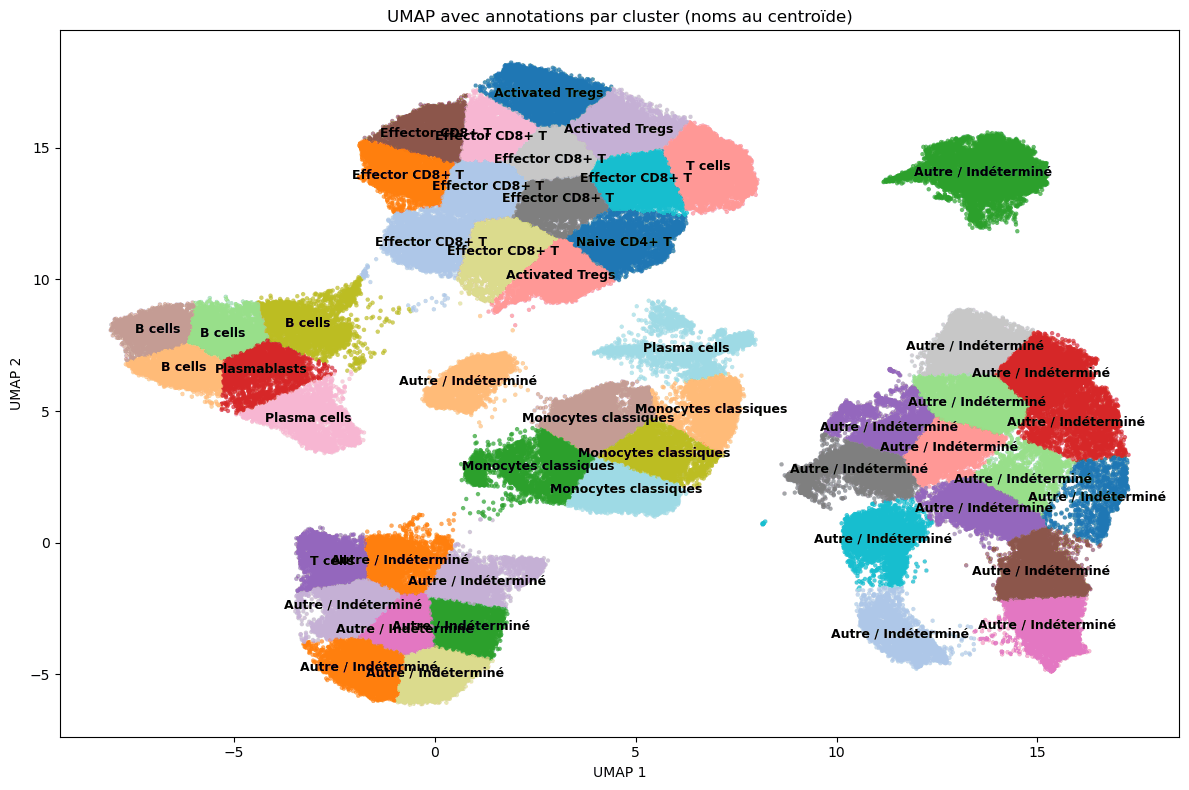

In [64]:
plot_umap_cluster_labels(umap2, clusters2, cluster_annotation)

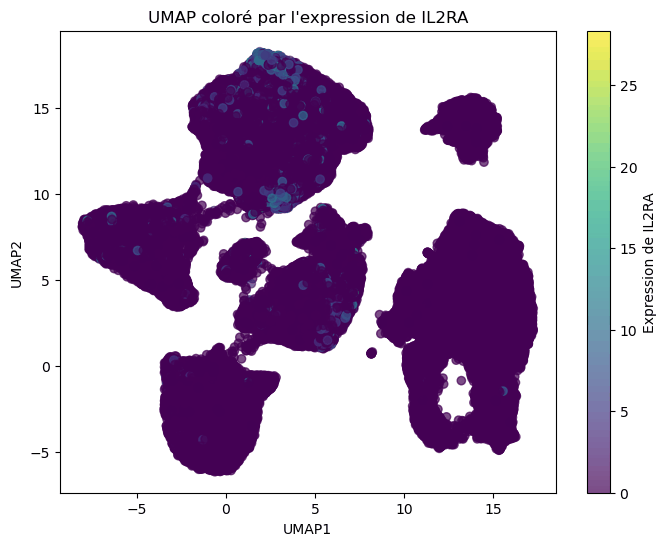

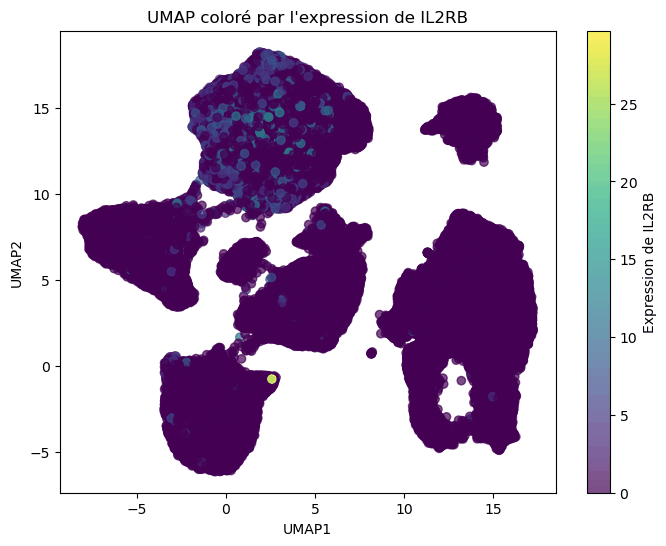

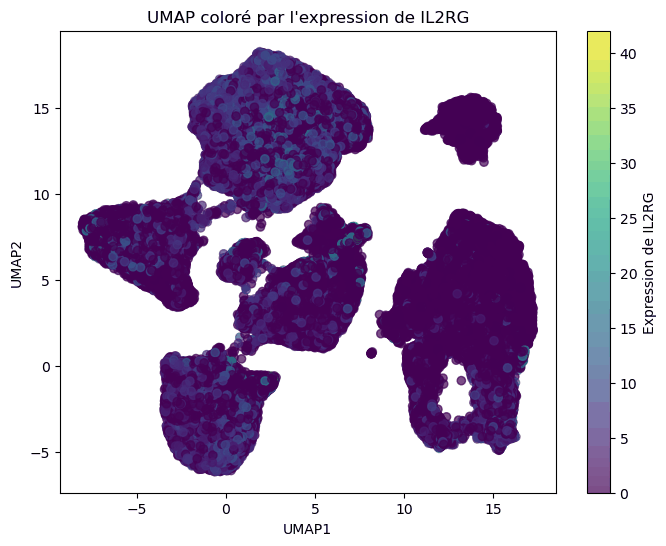

In [65]:
umap_coords = pd.DataFrame(umap2, columns=["UMAP1", "UMAP2"])

plot_gene_umap(umap_coords, df2_normalized, 'IL2RA')
plot_gene_umap(umap_coords, df2_normalized, 'IL2RB')
plot_gene_umap(umap_coords, df2_normalized, 'IL2RG')

### Distribution de nos gènes d'interets par clusters

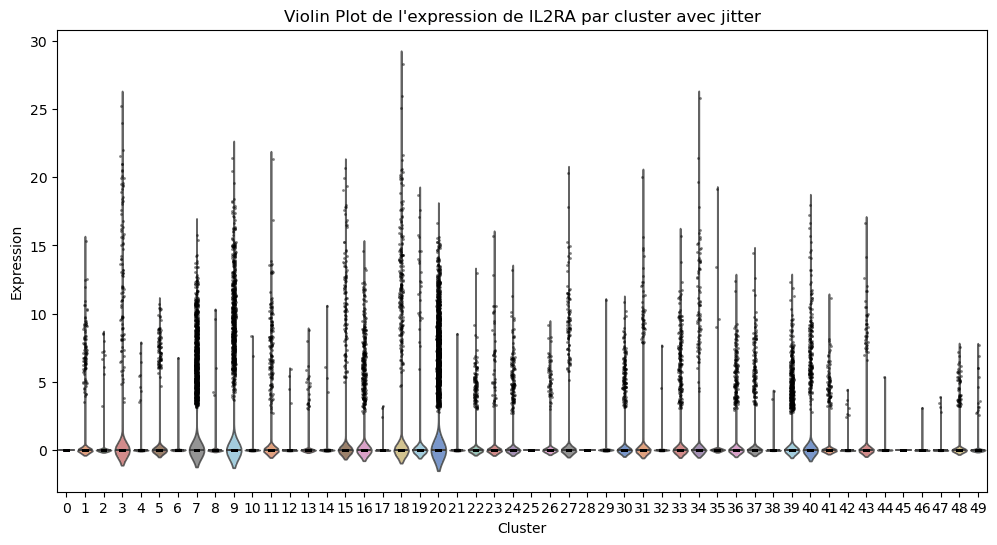

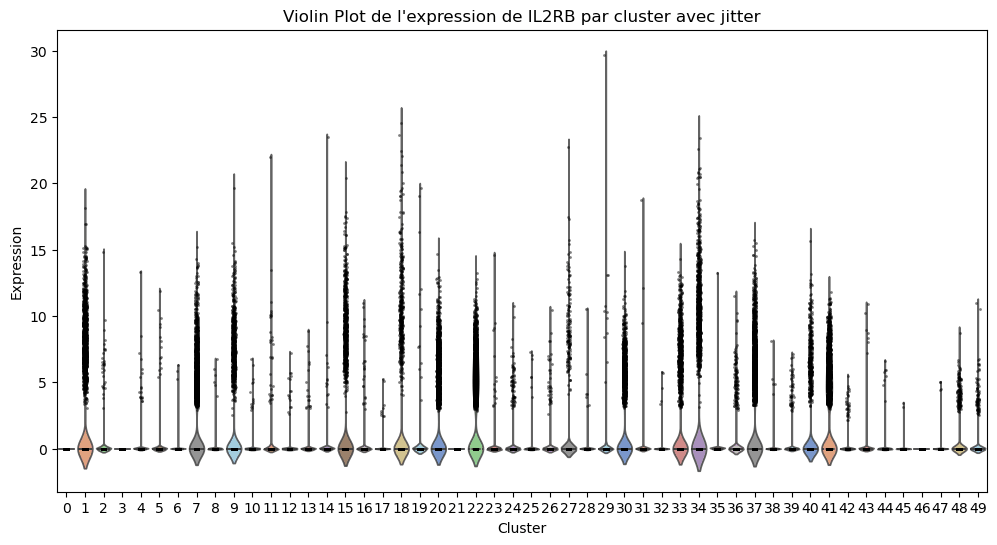

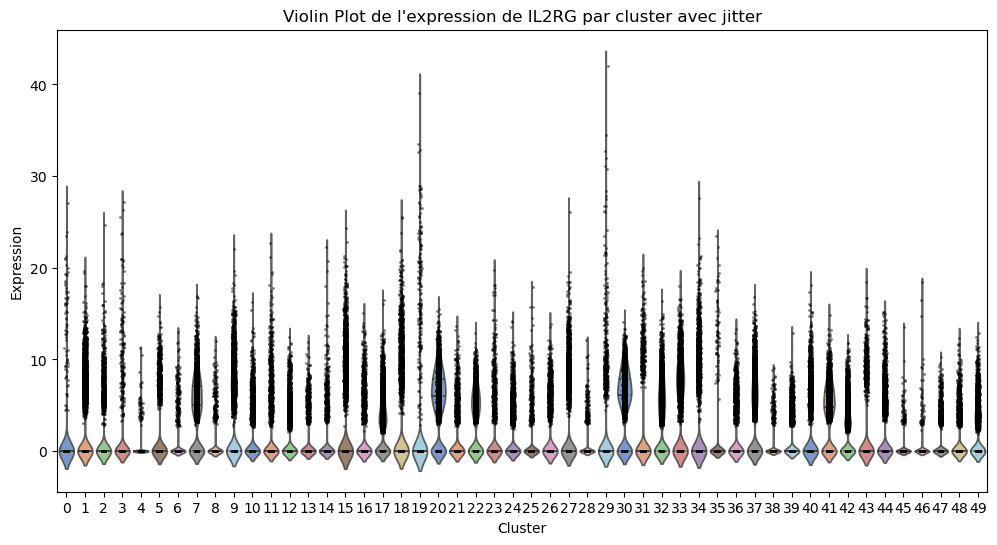

In [67]:
plot_violin(df2_normalized, ["IL2RA", "IL2RB", "IL2RG"], clusters2)

## On effectue les tests statistiques 

### T-test 

In [68]:

df2_cluster = pd.Series(clusters2, index= df2_normalized.columns)
print(type(df2_cluster))

<class 'pandas.core.series.Series'>


In [70]:
from scipy import stats
p_values_df_t_test = t_test_gene_expression_with_pvalues(df2_normalized, df2_cluster, genes_of_interest)

### Mann Whitney 

In [72]:
p_values_df_mann_whitney = mann_whitney_gene_expression(df2_normalized, df2_cluster, genes_of_interest)

## Visualisation des violins plots avec étoile significatives 

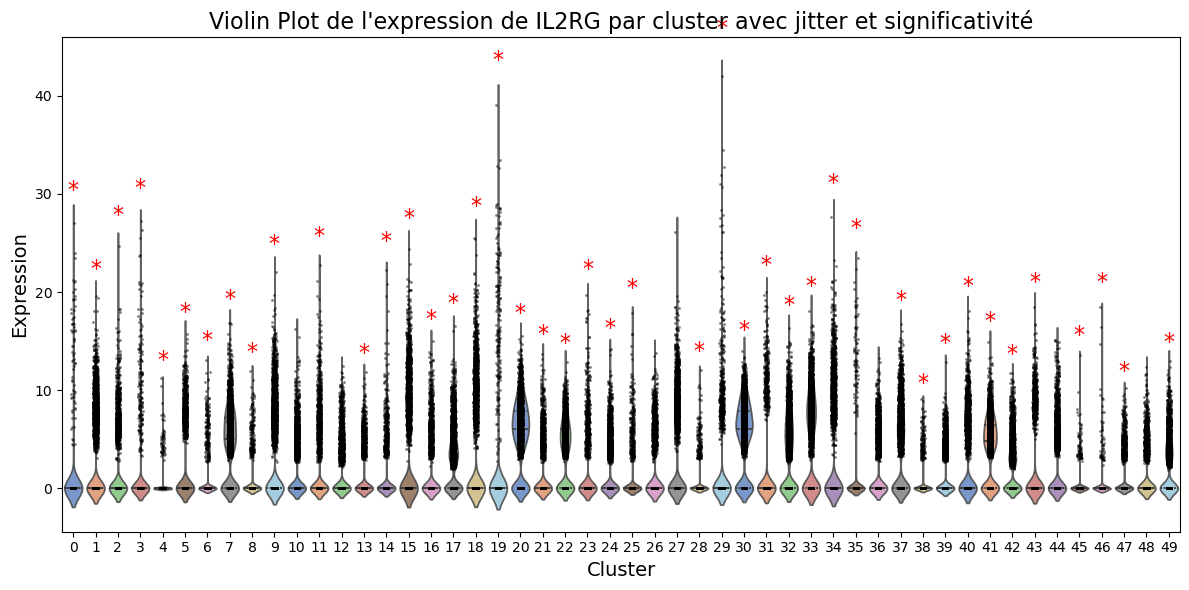

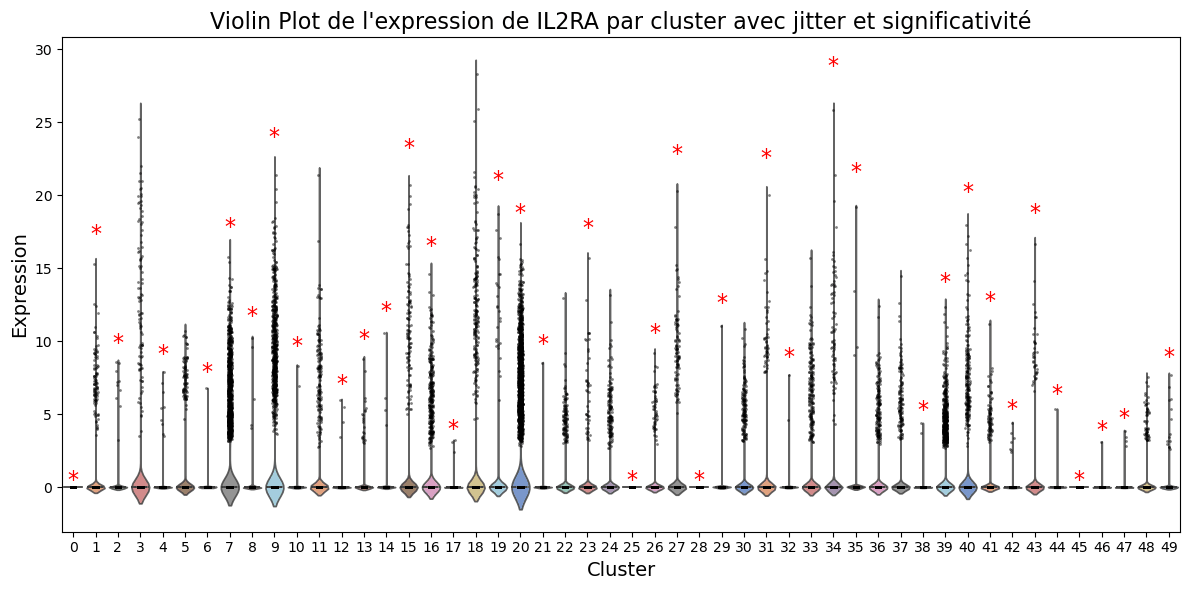

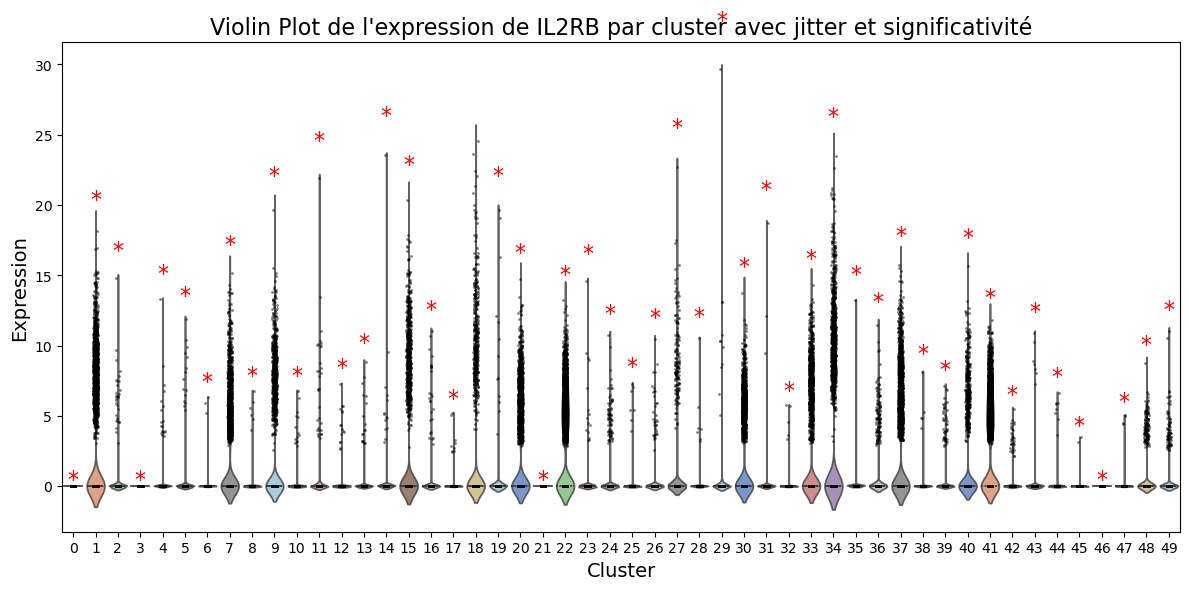

In [80]:
plot_violin_with_significance(df2_normalized, genes_of_interest, clusters2, p_values_df_mann_whitney, threshold=0.0001)